# Projeto: Análise de Abandono e Sucesso Académico

https://www.kaggle.com/code/jeevabharathis/student-dropout-analysis-for-school-education

A ideia principal é analisar o dataset de estudantes, perceber a distribuição das variáveis e construir uma primeira base de modelação para prever abandono escolar. Os nomes das colunas são mantidos em inglês, exatamente como vêm no dataset, para evitar confusão com documentação externa e com a fonte original.

## Célula 1 - Configuração inicial

Nesta célula são importadas as bibliotecas usadas ao longo do notebook. Também é definido um estado aleatório fixo para tornar os resultados reprodutíveis e são ajustadas algumas opções de visualização das tabelas e gráficos.

In [1]:
# Celula 1 - Configuracao inicial do ambiente
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.dummy import DummyClassifier

# Evita avisos repetidos que podem dificultar a leitura
warnings.filterwarnings('ignore')

# Valor fixo para garantir que a divisao treino/teste e os modelos sao reproduziveis.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Mostra mais colunas quando fazemos display de tabelas no notebook.
pd.set_option('display.max_columns', 80)
sns.set_theme(style='whitegrid')

print('Configuração concluida.')

Configuração concluida.


## Célula 2 - Carregamento do dataset

Nesta célula o notebook procura automaticamente um ficheiro `.csv` dentro da pasta `data/` e carrega-o para um `DataFrame`. O código também funciona se o notebook for aberto a partir da pasta do projeto principal ou diretamente dentro da pasta `iaa-project-1`.

Importante: aqui não são traduzidas colunas nem valores. O dataset fica com a estrutura original.

In [2]:
# Celula 2 - Localizacao e carregamento dos dados
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / 'data'

# Permite executar o notebook tanto na pasta iaa-project-1 como na pasta acima.
if not DATA_DIR.exists() and (PROJECT_ROOT / 'iaa-project-1' / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT / 'iaa-project-1'
    DATA_DIR = PROJECT_ROOT / 'data'

def find_first_csv(data_dir: Path):
    if not data_dir.exists():
        return None
    csv_files = sorted(data_dir.glob('*.csv'))
    return csv_files[0] if csv_files else None

DATA_PATH = find_first_csv(DATA_DIR)
TARGET_COL = 'Target'

if DATA_PATH is None:
    print("Não foi encontrado nenhum ficheiro CSV em 'data/'.")
    print('Coloca o dataset na pasta data/ ou define DATA_PATH manualmente.')
else:
    print(f'Dataset encontrado: {DATA_PATH}')

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig') if DATA_PATH is not None else pd.DataFrame()

print('Dimensão do dataset:', df.shape)

Dataset encontrado: /Users/goncalosimoes/Desktop/EI3A2S/IAA/Práticas/project/iaa-project-1/data/dataset.csv
Dimensão do dataset: (4424, 35)


## Célula 3 - Primeira inspeção dos dados

Esta célula serve para confirmar se o dataset foi carregado corretamente. São mostradas as primeiras linhas, os tipos de dados, o número de valores em falta e o número de linhas duplicadas. Esta etapa é importante antes de qualquer modelo, porque erros de carregamento ou problemas de qualidade podem afetar toda a análise.

In [3]:
# Celula 3 - Inspecao inicial do dataset
if df.empty:
    print('DataFrame vazío. Carrega primeiro o dataset.')
else:
    display(df.head())

    print()
    print('Tipos de dados:')
    display(df.dtypes.value_counts())

    missing_values = df.isna().sum()
    duplicate_count = df.duplicated().sum()

    if missing_values.any() or duplicate_count != 0:
        print('Erro: existem valores em falta e/ou linhas duplicadas.')
        display(missing_values[missing_values > 0].sort_values(ascending=False).head(10))
        print('Número de linhas duplicadas:', duplicate_count)
    else:
        print('Validação passou: Sem valores em falta e sem linhas duplicadas.')

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,10,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,4,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,10,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,4,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,10,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate



Tipos de dados:


int64      29
float64     5
object      1
Name: count, dtype: int64

Validação passou: Sem valores em falta e sem linhas duplicadas.


## Célula 4 - Estatísticas descritivas

Nesta célula são calculadas estatísticas simples das variáveis numéricas, como média, desvio padrão, mínimo e máximo. Isto ajuda a perceber a escala das variáveis e a detetar valores estranhos ou muito diferentes do esperado.

In [4]:
# Celula 4 - Estatisticas descritivas das variaveis numericas
if df.empty:
    print('DataFrame vazio.')
else:
    display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,6.886980,5.298964,1.00,1.00,8.000000,12.000000,18.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,9.899186,4.331792,1.00,6.00,10.000000,13.000000,17.000000
Daytime/evening attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,2.531420,3.963707,1.00,1.00,1.000000,1.000000,17.000000
Nacionality,4424.0,1.254521,1.748447,1.00,1.00,1.000000,1.000000,21.000000
Mother's qualification,4424.0,12.322107,9.026251,1.00,2.00,13.000000,22.000000,29.000000
Father's qualification,4424.0,16.455244,11.044800,1.00,3.00,14.000000,27.000000,34.000000
Mother's occupation,4424.0,7.317812,3.997828,1.00,5.00,6.000000,10.000000,32.000000


## Célula 5 - Distribuição da variável alvo

A coluna `Target` representa o resultado académico do estudante: `Dropout`, `Enrolled` ou `Graduate`. Aqui é analisada a distribuição dessas classes. Esta informação é essencial porque, se as classes estiverem desequilibradas, a avaliação do modelo não deve depender apenas da accuracy.

,contagem,percentagem
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


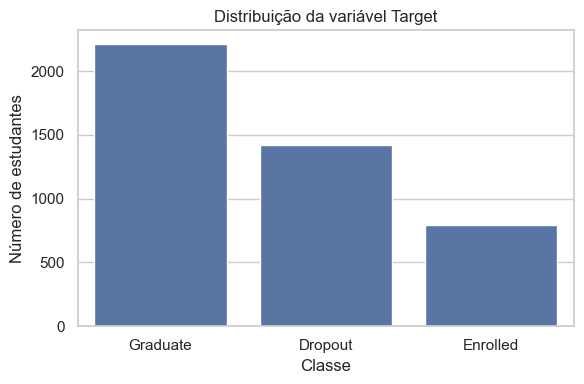

In [5]:
# Celula 5 - Analise da distribuicão da variável alvo

if df.empty:
    print('DataFrame vazio.')
elif TARGET_COL not in df.columns:
    print(f"Coluna '{TARGET_COL}' não encontrada.")
    print('Colunas disponíveis:')
    display(df.columns.to_series())
else:
    target_counts = df[TARGET_COL].value_counts(dropna=False)
    target_percentages = df[TARGET_COL].value_counts(normalize=True, dropna=False).mul(100).round(2)

    target_summary = pd.DataFrame({
        'contagem': target_counts,
        'percentagem': target_percentages
    })
    display(target_summary)

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=TARGET_COL, order=target_counts.index)
    plt.title('Distribuição da variável Target')
    plt.xlabel('Classe')
    plt.ylabel('Número de estudantes')
    plt.tight_layout()
    plt.show()

## Célula 6 - Relações entre variáveis académicas e Target

Nesta célula são escolhidas algumas variáveis académicas importantes, especialmente relacionadas com unidades curriculares aprovadas e notas. O objetivo é observar visualmente se existem diferenças entre estudantes que abandonam, continuam inscritos ou se graduam.

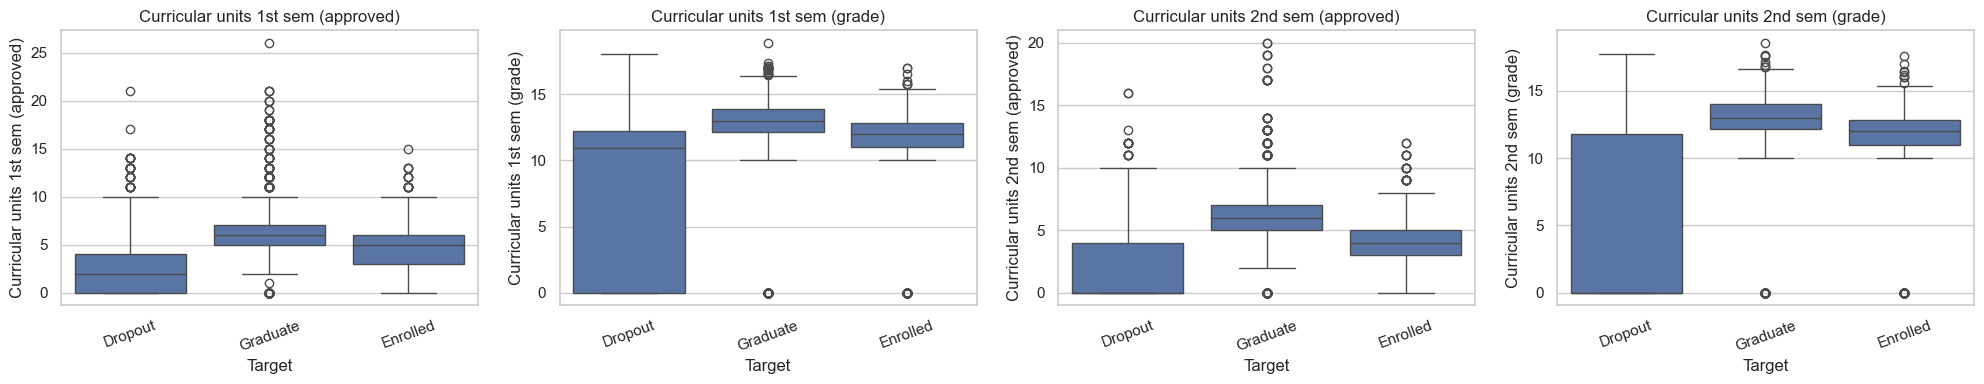

In [6]:
# Celula 6 - Exploracao visual de variaveis academicas relevantes
academic_features = [
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)'
]

if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para gerar graficos.')
else:
    available_features = [col for col in academic_features if col in df.columns]

    if not available_features:
        print('Nenhuma das variaveis academicas esperadas foi encontrada.')
    else:
        fig, axes = plt.subplots(1, len(available_features), figsize=(5 * len(available_features), 4))
        if len(available_features) == 1:
            axes = [axes]

        for ax, feature in zip(axes, available_features):
            sns.boxplot(data=df, x=TARGET_COL, y=feature, ax=ax)
            ax.set_title(feature)
            ax.set_xlabel('Target')
            ax.tick_params(axis='x', rotation=20)

        plt.tight_layout()
        plt.show()

## Célula 7 - Matriz de correlação

Esta célula mostra uma matriz de correlação para variáveis numéricas selecionadas. A correlação ajuda a perceber que variáveis tendem a variar em conjunto. Nesta fase serve sobretudo como apoio exploratório, não como prova de causalidade.

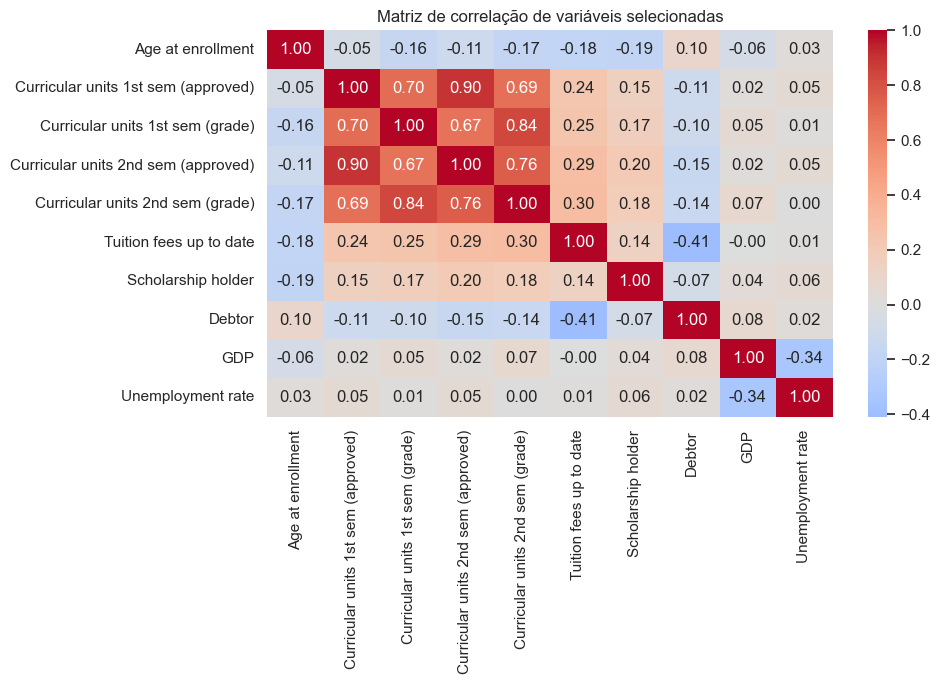

In [7]:
# Celula 7 - Correlação entre variaveis numericas selecionadas
if df.empty:
    print('DataFrame vazio.')
else:
    numeric_df = df.select_dtypes(include=np.number)
    selected_numeric_cols = [
        'Age at enrollment',
        'Curricular units 1st sem (approved)',
        'Curricular units 1st sem (grade)',
        'Curricular units 2nd sem (approved)',
        'Curricular units 2nd sem (grade)',
        'Tuition fees up to date',
        'Scholarship holder',
        'Debtor',
        'GDP',
        'Unemployment rate'
    ]
    selected_numeric_cols = [col for col in selected_numeric_cols if col in numeric_df.columns]

    if len(selected_numeric_cols) < 2:
        print('Variáveis numericas insuficientes para calcular correlação.')
    else:
        corr = numeric_df[selected_numeric_cols].corr()
        plt.figure(figsize=(10, 7))
        sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
        plt.title('Matriz de correlação de variáveis selecionadas')
        plt.tight_layout()
        plt.show()

## Célula 8 - Preparação do problema binário

Embora o dataset tenha três classes, para uma primeira etapa faz sentido focar o problema mais direto: distinguir estudantes em `Dropout` dos restantes. Assim, é criada uma nova variável `target_binary`, em que `1` representa abandono e `0` representa não abandono.

Depois os dados são divididos em treino e teste, mantendo a proporção das classes através de `stratify`.

In [8]:
# Celula 8 - Criacao do alvo binario e divisao treino/teste
if df.empty or TARGET_COL not in df.columns:
    print('Nao e possivel preparar dados sem dataset ou coluna Target.')
else:
    work_df = df.copy()

    # 1 significa estudante em abandono; 0 significa estudante inscrito ou graduado.
    work_df['target_binary'] = np.where(work_df[TARGET_COL].astype(str).str.lower() == 'dropout', 1, 0)

    X = work_df.drop(columns=[TARGET_COL, 'target_binary'])
    y_binary = work_df['target_binary']

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_binary,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_binary
    )

    print('Tamanho do treino:', X_train.shape)
    print('Tamanho do teste:', X_test.shape)
    print()
    print('Distribuicao do alvo binario no treino:')
    display(y_train.value_counts(normalize=True).rename('proporcao'))

Tamanho do treino: (3539, 34)
Tamanho do teste: (885, 34)

Distribuicao do alvo binario no treino:


target_binary
0    0.678723
1    0.321277
Name: proporcao, dtype: float64

## Célula 9 - Pipeline de pré-processamento

Nesta célula é definido o pré-processamento usado antes dos modelos. Variáveis numéricas recebem imputação pela mediana e normalização; variáveis categóricas recebem imputação pelo valor mais frequente e codificação one-hot. Mesmo que quase todas as variáveis sejam numéricas neste dataset, usar uma pipeline torna o processo mais robusto e organizado.

In [9]:
# Celula 9 - Definição do pré-processamento
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para criar o pré-processamento.')
else:
    numeric_selector = make_column_selector(dtype_include=np.number)
    categorical_selector = make_column_selector(dtype_exclude=np.number)

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ('numeric', numeric_pipeline, numeric_selector),
        ('categorical', categorical_pipeline, categorical_selector)
    ])

    print('Pré-processamento definido.')

Pré-processamento definido.


## Célula 10 - Comparação de modelos

Nesta célula são treinados e comparados vários modelos: Regressão Logística, Random Forest e modelos de boosting. A Regressão Logística funciona como modelo simples e interpretável; Random Forest e boosting permitem capturar relações não lineares e interações entre variáveis.

A comparação é feita com validação cruzada estratificada e várias métricas. A tabela final é apresentada em percentagem e ordenada pelo F1-score, para facilitar a leitura dos resultados.

Comparação por validação cruzada estratificada, valores em percentagem:


,accuracy,balanced_accuracy,f1,precision,recall,roc_auc
model,,,,,,
Gradient Boosting,87.62%,83.73%,79.09%,86.57%,72.82%,91.79%
Logistic Regression,86.13%,84.89%,79.08%,76.98%,81.44%,91.87%
Hist Gradient Boosting,86.63%,84.41%,78.99%,79.82%,78.19%,91.46%
Random Forest,86.95%,82.39%,77.41%,87.16%,69.65%,91.53%
AdaBoost,85.28%,81.44%,75.51%,81.03%,70.71%,89.91%


Melhor modelo por F1-score: Gradient Boosting (79.09%)


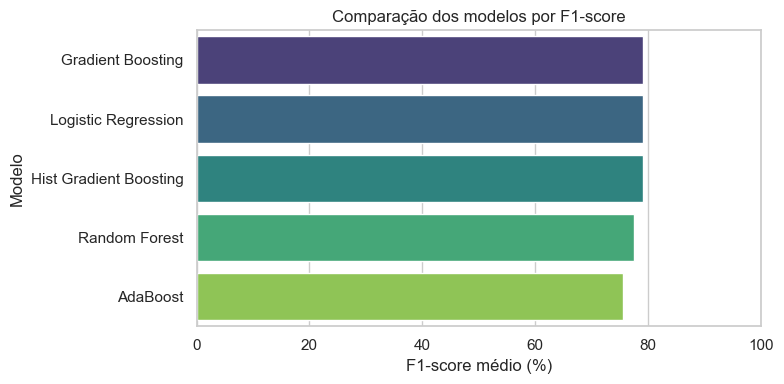

In [10]:
# Celula 10 - Comparacao de modelos com validacao cruzada
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para treinar modelos.')
else:
    models = {
        'Logistic Regression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=RANDOM_STATE),
        'AdaBoost': AdaBoostClassifier(n_estimators=150, learning_rate=0.05, random_state=RANDOM_STATE),
        'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE),
        'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, class_weight='balanced', random_state=RANDOM_STATE)
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = ['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall', 'roc_auc']

    cv_results = []

    for model_name, model in models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=scoring,
            n_jobs=1
        )

        summary = {metric: float(np.mean(scores[f'test_{metric}'])) for metric in scoring}
        summary['model'] = model_name
        cv_results.append(summary)

    cv_results_df = pd.DataFrame(cv_results).set_index('model').sort_values('f1', ascending=False)
    cv_results_percent = (cv_results_df * 100).round(2)

    print('Comparação por validação cruzada estratificada, valores em percentagem:')
    display(
        cv_results_percent.style
        .format('{:.2f}%')
        .highlight_max(axis=0, color='#d7f0d2')
        .set_caption('Resultados médios em 5 folds')
    )

    best_model_name = cv_results_df.index[0]
    print(f'Melhor modelo por F1-score: {best_model_name} ({cv_results_percent.loc[best_model_name, "f1"]:.2f}%)')

    plt.figure(figsize=(8, 4))
    sns.barplot(data=cv_results_percent.reset_index(), x='f1', y='model', palette='viridis')
    plt.title('Comparação dos modelos por F1-score')
    plt.xlabel('F1-score médio (%)')
    plt.ylabel('Modelo')
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

## Célula 11 - Avaliação no conjunto de teste

Depois da validação cruzada, o melhor modelo é treinado no conjunto de treino completo e avaliado no conjunto de teste. Os resultados são apresentados numa tabela em percentagem e a matriz de confusão também é normalizada em percentagem por classe real, o que torna mais fácil comparar acertos e erros entre classes.

Melhor modelo: Gradient Boosting
Accuracy no conjunto de teste: 87.57%
Resultados no conjunto de teste:


,precision,recall,f1-score,support
Non-Dropout,88.30%,94.18%,91.14%,601
Dropout,85.66%,73.59%,79.17%,284
macro avg,86.98%,83.88%,85.15%,885
weighted avg,87.45%,87.57%,87.30%,885


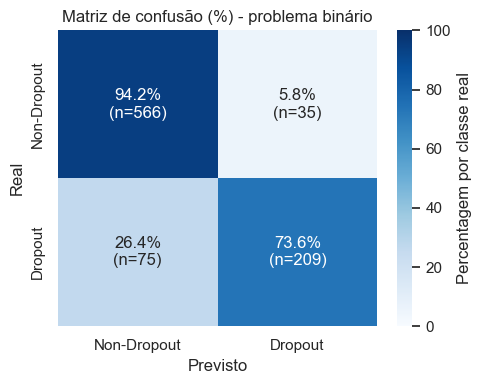

In [11]:
# Celula 11 - Avaliacao final do melhor modelo no conjunto de teste
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para a avaliação final.')
else:
    best_model_name = cv_results_df.index[0]
    best_model = models[best_model_name]

    best_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', best_model)
    ])

    best_pipeline.fit(X_train, y_train)
    y_pred = best_pipeline.predict(X_test)

    report = classification_report(
        y_test,
        y_pred,
        target_names=['Non-Dropout', 'Dropout'],
        output_dict=True,
        zero_division=0
    )
    report_df = pd.DataFrame(report).T
    metric_cols = ['precision', 'recall', 'f1-score']
    report_rows = ['Non-Dropout', 'Dropout', 'macro avg', 'weighted avg']
    report_percent = report_df.loc[report_rows, metric_cols + ['support']].copy()
    report_percent[metric_cols] = report_percent[metric_cols] * 100
    report_percent['support'] = report_percent['support'].astype(int)
    test_accuracy = report['accuracy'] * 100

    print('Melhor modelo:', best_model_name)
    print(f'Accuracy no conjunto de teste: {test_accuracy:.2f}%')
    print('Resultados no conjunto de teste:')
    display(
        report_percent.style
        .format({'precision': '{:.2f}%', 'recall': '{:.2f}%', 'f1-score': '{:.2f}%', 'support': '{:.0f}'})
        .highlight_max(subset=metric_cols, axis=0, color='#d7f0d2')
    )

    cm = confusion_matrix(y_test, y_pred)
    cm_percent = confusion_matrix(y_test, y_pred, normalize='true') * 100
    cm_labels = np.array([
        [f'{cm_percent[i, j]:.1f}%\n(n={cm[i, j]})' for j in range(cm.shape[1])]
        for i in range(cm.shape[0])
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm_percent,
        annot=cm_labels,
        fmt='',
        cmap='Blues',
        vmin=0,
        vmax=100,
        cbar_kws={'label': 'Percentagem por classe real'},
        xticklabels=['Non-Dropout', 'Dropout'],
        yticklabels=['Non-Dropout', 'Dropout']
    )
    plt.title('Matriz de confusão (%) - problema binário')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()

## Célula 12 - Importância das variáveis

Esta célula mostra as variáveis com maior importância para o melhor modelo através de permutation importance. Esta abordagem funciona com diferentes tipos de modelos, incluindo modelos de boosting, e ajuda a explicar que fatores estão a influenciar mais a previsão.

Importância das variáveis calculada para: Gradient Boosting


,importance
Curricular units 2nd sem (approved),0.2320
Tuition fees up to date,0.0770
Scholarship holder,0.0116
Age at enrollment,0.0075
Curricular units 1st sem (approved),0.0070
Unemployment rate,0.0050
Curricular units 2nd sem (credited),0.0045
Curricular units 1st sem (credited),0.0043
GDP,0.0030
Curricular units 1st sem (evaluations),0.0018


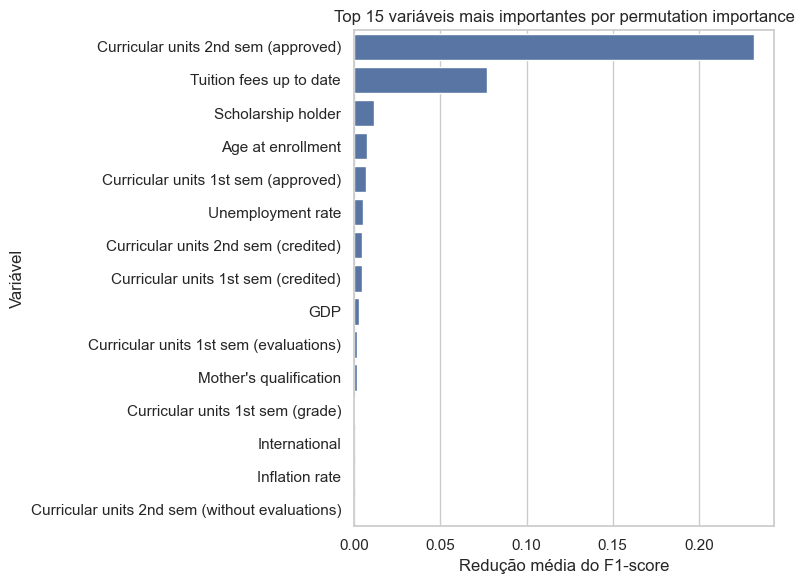

In [ ]:
# Celula 12 - Importância das variáveis para o melhor modelo
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para calcular importância de variáveis.')
else:
    permutation = permutation_importance(
        best_pipeline,
        X_test,
        y_test,
        n_repeats=3,
        random_state=RANDOM_STATE,
        scoring='f1',
        n_jobs=1
    )
    importances = pd.Series(permutation.importances_mean, index=X_test.columns)
    top_importances = importances.sort_values(ascending=False).head(15)

    print(f'Importância das variáveis calculada para: {best_model_name}')
    display(top_importances.rename('importance').to_frame().style.format('{:.4f}'))

    plt.figure(figsize=(8, 6))
    sns.barplot(x=top_importances.values, y=top_importances.index)
    plt.title('Top 15 variáveis mais importantes por permutation importance')
    plt.xlabel('Redução média do F1-score')
    plt.ylabel('Variável')
    plt.tight_layout()
    plt.show()

## Célula 13 - Baseline e controlo de overfitting

Antes de interpretar o melhor modelo, é útil compará-lo com um modelo ingénuo e medir a diferença entre desempenho em treino e validação cruzada. Isto ajuda a justificar que o modelo aprendeu padrões reais e não apenas memorizou o conjunto de treino. Um intervalo grande entre treino e validação é sinal de possível overfitting; resultados fracos em ambos indicam underfitting.

In [13]:
# Celula 13 - Baseline e diagnostico simples de overfitting/underfitting
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para diagnosticar overfitting/underfitting.')
else:
    diagnostic_models = {
        'Dummy baseline': DummyClassifier(strategy='most_frequent'),
        **models
    }

    diagnostic_rows = []
    for model_name, model in diagnostic_models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring={'f1': 'f1', 'balanced_accuracy': 'balanced_accuracy'},
            return_train_score=True,
            n_jobs=1
        )

        diagnostic_rows.append({
            'model': model_name,
            'train_f1': scores['train_f1'].mean(),
            'cv_f1': scores['test_f1'].mean(),
            'gap_f1': scores['train_f1'].mean() - scores['test_f1'].mean(),
            'cv_balanced_accuracy': scores['test_balanced_accuracy'].mean()
        })

    overfitting_df = pd.DataFrame(diagnostic_rows).set_index('model').sort_values('cv_f1', ascending=False)
    overfitting_percent = (overfitting_df * 100).round(2)

    print('Diagnóstico treino vs validação cruzada, valores em percentagem:')
    display(
        overfitting_percent.style
        .format('{:.2f}%')
        .highlight_max(subset=['cv_f1', 'cv_balanced_accuracy'], color='#d7f0d2')
        .highlight_min(subset=['gap_f1'], color='#d7f0d2')
    )

    best_gap = overfitting_df.loc[best_model_name, 'gap_f1'] * 100
    if best_gap > 8:
        interpretation = 'possível overfitting: a diferença entre treino e validação é relevante.'
    elif overfitting_df.loc[best_model_name, 'cv_f1'] < 0.65:
        interpretation = 'possível underfitting: o desempenho em validação ainda é limitado.'
    else:
        interpretation = 'sem sinal forte de overfitting ou underfitting nos resultados médios.'

    print(f'Interpretação para {best_model_name}: {interpretation}')

Diagnóstico treino vs validação cruzada, valores em percentagem:


,train_f1,cv_f1,gap_f1,cv_balanced_accuracy
model,,,,
Gradient Boosting,82.64%,79.09%,3.55%,83.73%
Logistic Regression,80.02%,79.08%,0.94%,84.89%
Hist Gradient Boosting,96.32%,78.99%,17.33%,84.41%
Random Forest,100.00%,77.41%,22.59%,82.39%
AdaBoost,75.52%,75.51%,0.01%,81.44%
Dummy baseline,0.00%,0.00%,0.00%,50.00%


Interpretação para Gradient Boosting: sem sinal forte de overfitting ou underfitting nos resultados médios.


## Célula 14 - Avaliação final do melhor modelo

A avaliação final é feita no conjunto de teste, usando o melhor modelo escolhido pela validação cruzada. O teste fica separado da escolha do modelo, tornando a estimativa de desempenho mais honesta.

Modelo final: Gradient Boosting
Accuracy no teste: 87.57%


,precision,recall,f1-score,support
Non-Dropout,88.30%,94.18%,91.14%,601
Dropout,85.66%,73.59%,79.17%,284
macro avg,86.98%,83.88%,85.15%,885
weighted avg,87.45%,87.57%,87.30%,885


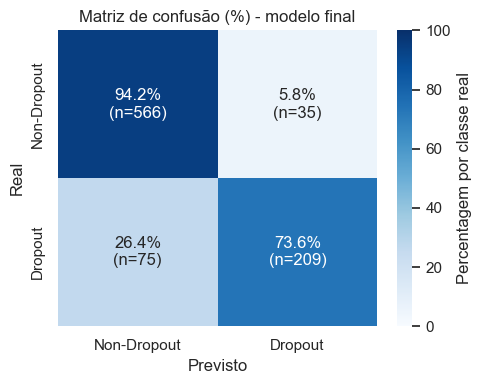

In [14]:
# Celula 14 - Avaliacao final do melhor modelo no conjunto de teste
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para avaliar o melhor modelo.')
else:
    final_pipeline = best_pipeline
    final_model_name = best_model_name
    final_y_pred = final_pipeline.predict(X_test)
    final_report = classification_report(
        y_test,
        final_y_pred,
        target_names=['Non-Dropout', 'Dropout'],
        output_dict=True,
        zero_division=0
    )
    final_report_df = pd.DataFrame(final_report).T
    final_report_percent = final_report_df.loc[report_rows, metric_cols + ['support']].copy()
    final_report_percent[metric_cols] = final_report_percent[metric_cols] * 100
    final_report_percent['support'] = final_report_percent['support'].astype(int)

    print('Modelo final:', final_model_name)
    print(f'Accuracy no teste: {final_report["accuracy"] * 100:.2f}%')
    display(
        final_report_percent.style
        .format({'precision': '{:.2f}%', 'recall': '{:.2f}%', 'f1-score': '{:.2f}%', 'support': '{:.0f}'})
        .highlight_max(subset=metric_cols, axis=0, color='#d7f0d2')
    )

    final_cm = confusion_matrix(y_test, final_y_pred)
    final_cm_percent = confusion_matrix(y_test, final_y_pred, normalize='true') * 100
    final_cm_labels = np.array([
        [f'{final_cm_percent[i, j]:.1f}%\n(n={final_cm[i, j]})' for j in range(final_cm.shape[1])]
        for i in range(final_cm.shape[0])
    ])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        final_cm_percent,
        annot=final_cm_labels,
        fmt='',
        cmap='Blues',
        vmin=0,
        vmax=100,
        cbar_kws={'label': 'Percentagem por classe real'},
        xticklabels=['Non-Dropout', 'Dropout'],
        yticklabels=['Non-Dropout', 'Dropout']
    )
    plt.title('Matriz de confusão (%) - modelo final')
    plt.xlabel('Previsto')
    plt.ylabel('Real')
    plt.tight_layout()
    plt.show()


## Célula 15 - Problema multiclasse original

O problema binário é útil para identificar risco de abandono, mas o dataset original tem três estados: `Dropout`, `Enrolled` e `Graduate`. Esta célula avalia também essa formulação, mostrando que a escolha do alvo é uma decisão de modelação e não apenas um detalhe técnico.

In [15]:
# Celula 15 - Avaliacao alternativa do problema multiclasse original
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para avaliar o problema multiclasse.')
else:
    X_multi = df.drop(columns=[TARGET_COL])
    y_multi = df[TARGET_COL]

    X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(
        X_multi,
        y_multi,
        test_size=0.2,
        random_state=RANDOM_STATE,
        stratify=y_multi
    )

    multiclass_models = {
        'Logistic Regression': LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE),
        'Random Forest': RandomForestClassifier(n_estimators=250, class_weight='balanced', random_state=RANDOM_STATE),
        'Hist Gradient Boosting': HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, class_weight='balanced', random_state=RANDOM_STATE)
    }

    multiclass_rows = []
    for model_name, model in multiclass_models.items():
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])
        scores = cross_validate(
            pipeline,
            X_train_multi,
            y_train_multi,
            cv=cv,
            scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
            n_jobs=1
        )
        multiclass_rows.append({
            'model': model_name,
            'accuracy': scores['test_accuracy'].mean(),
            'balanced_accuracy': scores['test_balanced_accuracy'].mean(),
            'f1_macro': scores['test_f1_macro'].mean()
        })

    multiclass_results_df = pd.DataFrame(multiclass_rows).set_index('model').sort_values('f1_macro', ascending=False)
    multiclass_percent = multiclass_results_df.mul(100).round(2)

    print('Comparação multiclasse por validação cruzada, valores em percentagem:')
    display(
        multiclass_percent.style
        .format('{:.2f}%')
        .highlight_max(axis=0, color='#d7f0d2')
    )

    best_multiclass_name = multiclass_results_df.index[0]
    best_multiclass_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', multiclass_models[best_multiclass_name])
    ])
    best_multiclass_pipeline.fit(X_train_multi, y_train_multi)
    y_pred_multi = best_multiclass_pipeline.predict(X_test_multi)

    multi_report = classification_report(y_test_multi, y_pred_multi, output_dict=True, zero_division=0)
    multi_report_df = pd.DataFrame(multi_report).T
    multi_classes = best_multiclass_pipeline.named_steps['model'].classes_
    multi_rows = list(multi_classes) + ['macro avg', 'weighted avg']
    multi_report_percent = multi_report_df.loc[multi_rows, metric_cols + ['support']].copy()
    multi_report_percent[metric_cols] = multi_report_percent[metric_cols] * 100
    multi_report_percent['support'] = multi_report_percent['support'].astype(int)

    print('Melhor modelo multiclasse:', best_multiclass_name)
    display(
        multi_report_percent.style
        .format({'precision': '{:.2f}%', 'recall': '{:.2f}%', 'f1-score': '{:.2f}%', 'support': '{:.0f}'})
    )

Comparação multiclasse por validação cruzada, valores em percentagem:


,accuracy,balanced_accuracy,f1_macro
model,,,
Hist Gradient Boosting,77.08%,71.35%,71.74%
Logistic Regression,74.82%,71.32%,70.62%
Random Forest,77.56%,68.08%,69.24%


Melhor modelo multiclasse: Hist Gradient Boosting


,precision,recall,f1-score,support
Dropout,81.75%,72.54%,76.87%,284
Enrolled,46.81%,55.35%,50.72%,159
Graduate,83.60%,84.16%,83.88%,442
macro avg,70.72%,70.68%,70.49%,885
weighted avg,76.39%,75.25%,75.67%,885


## Célula 16 - Desempenho por subgrupos e responsabilidade

Como o tema envolve estudantes, a previsão não deve ser vista como uma decisão automática. Esta célula mede o desempenho por alguns subgrupos disponíveis no dataset. Diferenças grandes entre grupos podem indicar risco de tratamento desigual, necessidade de recolher mais contexto ou necessidade de usar o modelo apenas como apoio a intervenção humana.

In [ ]:
# Celula 16 - Analise de desempenho por subgrupos
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para analisar subgrupos.')
else:
    subgroup_columns = ['Gender', 'Scholarship holder', 'Debtor', 'Tuition fees up to date']
    subgroup_columns = [col for col in subgroup_columns if col in X_test.columns]

    subgroup_rows = []
    for col in subgroup_columns:
        for value in sorted(X_test[col].dropna().unique()):
            mask = X_test[col] == value
            support = int(mask.sum())
            positives = int(y_test[mask].sum())
            if support < 30 or len(np.unique(y_test[mask])) < 2:
                continue
            subgroup_rows.append({
                'subgroup': col,
                'value': value,
                'support': support,
                'dropout_rate': y_test[mask].mean(),
                'recall_dropout': classification_report(
                    y_test[mask],
                    final_y_pred[mask],
                    output_dict=True,
                    zero_division=0
                )['1']['recall'], # pyright: ignore[reportArgumentType]
                'f1_dropout': f1_score(y_test[mask], final_y_pred[mask], zero_division=0)
            })

    subgroup_df = pd.DataFrame(subgroup_rows)
    if subgroup_df.empty:
        print('Não há subgrupos com dimensão suficiente para uma leitura estável.')
    else:
        subgroup_display = subgroup_df.copy()
        for col in ['dropout_rate', 'recall_dropout', 'f1_dropout']:
            subgroup_display[col] = subgroup_display[col] * 100

        display(
            subgroup_display.sort_values(['subgroup', 'value']).style
            .format({'dropout_rate': '{:.2f}%', 'recall_dropout': '{:.2f}%', 'f1_dropout': '{:.2f}%'})
        )

        fairness_summary = subgroup_df.groupby('subgroup')['recall_dropout'].agg(['min', 'max'])
        fairness_summary['gap'] = fairness_summary['max'] - fairness_summary['min']
        fairness_summary = (fairness_summary * 100).round(2)
        print('Diferença de recall da classe Dropout entre valores de cada subgrupo:')
        display(fairness_summary.style.format('{:.2f}%'))

,subgroup,value,support,dropout_rate,recall_dropout,f1_dropout
4,Debtor,0,795,29.18%,70.26%,77.62%
5,Debtor,1,90,57.78%,88.46%,85.19%
0,Gender,0,564,24.47%,72.46%,78.12%
1,Gender,1,321,45.48%,74.66%,80.15%
2,Scholarship holder,0,654,38.99%,75.69%,80.58%
3,Scholarship holder,1,231,12.55%,55.17%,65.31%
6,Tuition fees up to date,0,114,85.96%,97.96%,95.05%
7,Tuition fees up to date,1,771,24.12%,60.75%,69.33%


Diferença de recall da classe Dropout entre valores de cada subgrupo:


,min,max,gap
subgroup,,,
Debtor,70.26%,88.46%,18.20%
Gender,72.46%,74.66%,2.19%
Scholarship holder,55.17%,75.69%,20.51%
Tuition fees up to date,60.75%,97.96%,37.21%


## Célula 17 - Conclusão crítica

In [ ]:
# Celula 17 - Síntese automática dos principais resultados
if df.empty or TARGET_COL not in df.columns:
    print('Dados insuficientes para gerar síntese.')
else:
    dropout_f1 = final_report['Dropout']['f1-score'] * 100                                  # pyright: ignore[reportArgumentType]
    dropout_recall = final_report['Dropout']['recall'] * 100                                # pyright: ignore[reportArgumentType]
    non_dropout_f1 = final_report['Non-Dropout']['f1-score'] * 100                          # pyright: ignore[reportArgumentType]
    final_accuracy = final_report['accuracy'] * 100                                         # pyright: ignore[reportArgumentType]
    top_features_text = ', '.join(top_importances.head(5).index.tolist())

    print('Resumo final:')
    print(f'- Formulação principal: classificação binária Dropout vs Non-Dropout, porque o objetivo prático é sinalizar risco de abandono.')
    print(f'- Melhor modelo final: {final_model_name}, escolhido por F1-score em validação cruzada e avaliado no teste.')
    print(f'- No teste, accuracy={final_accuracy:.2f}%, F1 Dropout={dropout_f1:.2f}%, recall Dropout={dropout_recall:.2f}% e F1 Non-Dropout={non_dropout_f1:.2f}%.')
    print(f'- Variáveis mais influentes por permutation importance: {top_features_text}.')
    print('- Overfitting/underfitting: a comparação treino vs validação cruzada permite discutir se o modelo generaliza ou se existe diferença excessiva entre treino e validação.')
    print('- Limitações: as variáveis codificadas numericamente precisam de documentação externa para interpretação completa; correlação e importância não provam causalidade; resultados dependem do contexto institucional do dataset.')
    print('- Ética: o modelo deve apoiar equipas humanas na identificação precoce de estudantes em risco, não decidir sanções ou exclusões. Recomenda-se monitorização por subgrupos, transparência e revisão periódica.')
    print('- Ferramentas de IA usadas: Codex/OpenAI foi usado para apoiar melhoria de código, estrutura do notebook e redação crítica; as decisões finais foram revistas e assumidas pelos estudantes.')

Resumo final:
- Formulação principal: classificação binária Dropout vs Non-Dropout, porque o objetivo prático é sinalizar risco de abandono.
- Melhor modelo final: Gradient Boosting, escolhido por F1-score em validação cruzada e avaliado no teste.
- No teste, accuracy=87.57%, F1 Dropout=79.17%, recall Dropout=73.59% e F1 Non-Dropout=91.14%.
- Variáveis mais influentes por permutation importance: Curricular units 2nd sem (approved), Tuition fees up to date, Scholarship holder, Age at enrollment, Curricular units 1st sem (approved).
- Overfitting/underfitting: a comparação treino vs validação cruzada permite discutir se o modelo generaliza ou se existe diferença excessiva entre treino e validação.
- Limitações: as variáveis codificadas numericamente precisam de documentação externa para interpretação completa; correlação e importância não provam causalidade; resultados dependem do contexto institucional do dataset.
- Ética: o modelo deve apoiar equipas humanas na identificação precoce de

## Resumo

O notebook inclui agora pipeline de dados, validação cruzada, baseline, diagnóstico de overfitting/underfitting, avaliação no teste, interpretação por importância de variáveis, formulação multiclasse e análise ética por subgrupos.